TASK 1: DATA QUALITY ASSESSMENT

Rows: 6607, Columns: 20

Data Types:
Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object

Missing Values:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities 

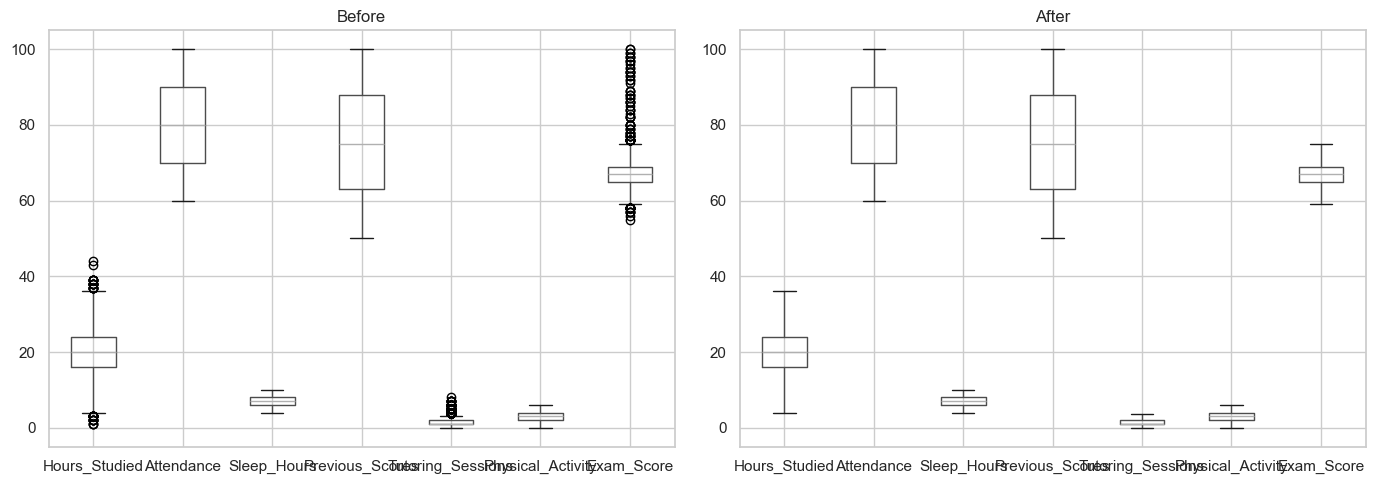


TASK 4: NORMALIZATION

Min-Max - Min: [0. 0. 0. 0. 0. 0. 0.]
Min-Max - Max: [1. 1. 1. 1. 1. 1. 1.]
Z-score - Mean: [-0. -0. -0.  0. -0. -0. -0.]
Z-score - Std: [1. 1. 1. 1. 1. 1. 1.]

TASK 5: PCA (Conditional on Correlation)


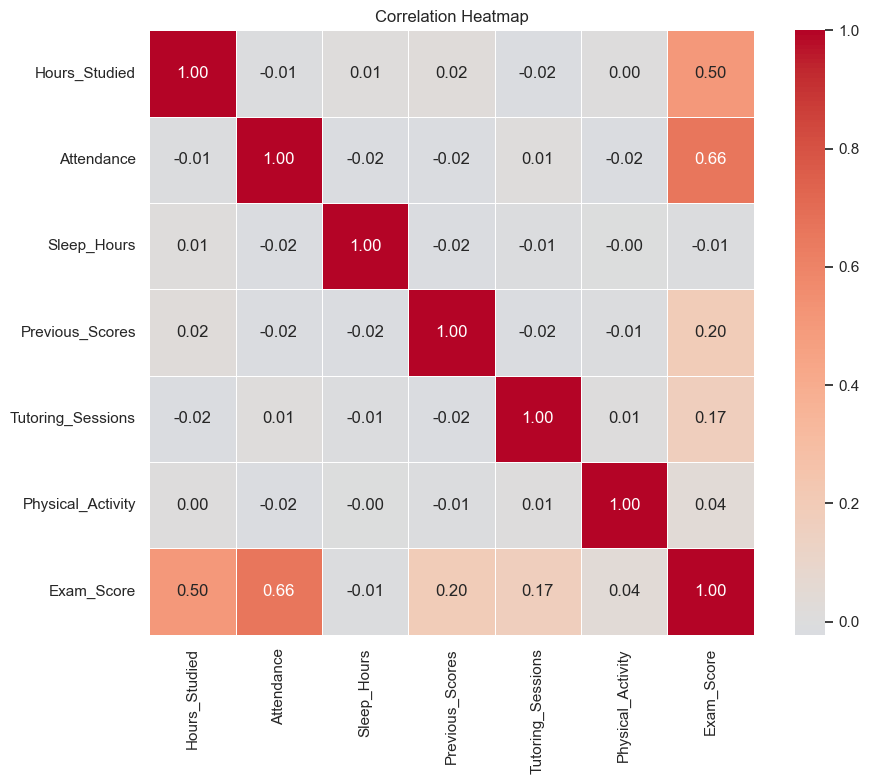


Maximum correlation: 0.66

Explained Variance Ratio: [0.26659622 0.15039221]
Total Variance Explained: 41.70%


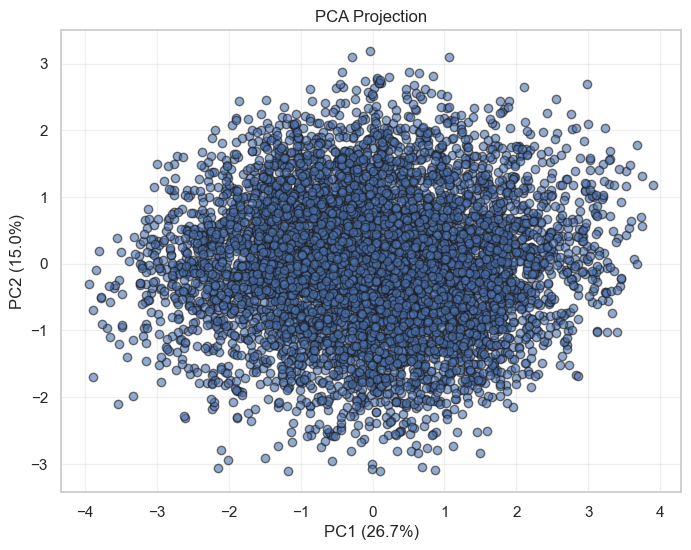

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

sns.set(style='whitegrid')

df = pd.read_csv('StudentPerformanceFactors.csv')

print("=" * 60)
print("TASK 1: DATA QUALITY ASSESSMENT")
print("=" * 60)

print(f"\nRows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isna().sum()}")
print(f"\nDuplicate Rows: {df.duplicated().sum()}")
print(f"\nFirst 5 Rows:\n{df.head()}")
print(f"\nStatistical Summary:\n{df.describe()}")


print("\n" + "=" * 60)
print("TASK 2: MISSING VALUE STRATEGY")
print("=" * 60)

missing_cols = df.columns[df.isna().any()].tolist()
df_clean = df.copy()

if missing_cols:
    print(f"\nColumns with missing values: {missing_cols}")
    
    for col in missing_cols:
        if df[col].dtype in ['int64', 'float64']:
            df_clean[col] = df_clean[col].fillna(df[col].median())
            print(f"\n   {col}: Strategy: Median Imputation")
else:
    print("\nNo missing values found in the dataset!")

print(f"\nMissing values after imputation: {df_clean.isna().sum().sum()}")

print("\nStrategy used: Median Imputation")
print("Why this strategy?")
print("- Median Imputation: More robust to outliers than the mean")
print("- Median Imputation: Preferred for skewed data distributions")

print("\n" + "=" * 60)
print("TASK 3: OUTLIER DETECTION AND HANDLING (IQR)")
print("=" * 60)

numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
df_no_outliers = df_clean.copy()

for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_no_outliers[col] = df_no_outliers[col].clip(lower_bound, upper_bound)

if len(numerical_cols) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    df_clean[numerical_cols].boxplot(ax=axes[0])
    axes[0].set_title('Before')
    df_no_outliers[numerical_cols].boxplot(ax=axes[1])
    axes[1].set_title('After')
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 60)
print("TASK 4: NORMALIZATION")
print("=" * 60)

numerical_cols_norm = df_no_outliers.select_dtypes(include=['int64', 'float64']).columns.tolist()

scaler_minmax = MinMaxScaler()
df_minmax = df_no_outliers.copy()
df_minmax[numerical_cols_norm] = scaler_minmax.fit_transform(df_no_outliers[numerical_cols_norm])

scaler_zscore = StandardScaler()
df_zscore = df_no_outliers.copy()
df_zscore[numerical_cols_norm] = scaler_zscore.fit_transform(df_no_outliers[numerical_cols_norm])

print(f"\nMin-Max - Min: {df_minmax[numerical_cols_norm].min().values}")
print(f"Min-Max - Max: {df_minmax[numerical_cols_norm].max().values}")
print(f"Z-score - Mean: {df_zscore[numerical_cols_norm].mean().values.round(2)}")
print(f"Z-score - Std: {df_zscore[numerical_cols_norm].std().values.round(2)}")

print("\n" + "=" * 60)
print("TASK 5: PCA (Conditional on Correlation)")
print("=" * 60)

if len(numerical_cols_norm) >= 2:
    correlation_matrix = df_zscore[numerical_cols_norm].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                fmt='.2f', square=True, linewidths=0.5)
    plt.title('Correlation Heatmap')
    plt.tight_layout()
    plt.show()
    
    corr_values = correlation_matrix.values
    np.fill_diagonal(corr_values, 0)
    max_corr = np.abs(corr_values).max()
    
    print(f"\nMaximum correlation: {max_corr:.2f}")
    
    if max_corr >= 0.3:
        pca = PCA(n_components=min(2, len(numerical_cols_norm)))
        principal_components = pca.fit_transform(df_zscore[numerical_cols_norm])
        
        print(f"\nExplained Variance Ratio: {pca.explained_variance_ratio_}")
        print(f"Total Variance Explained: {sum(pca.explained_variance_ratio_)*100:.2f}%")
        
        if principal_components.shape[1] >= 2:
            plt.figure(figsize=(8, 6))
            plt.scatter(principal_components[:, 0], principal_components[:, 1], 
                       alpha=0.6, edgecolors='k')
            plt.title('PCA Projection')
            plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
            plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
            plt.grid(True, alpha=0.3)
            plt.show()

print("\n" + "=" * 60)